# PCA Residual Topology

This notebook tests the residual-geometry hypothesis: after fitting family-level PCA on training data only, subtract the PCA reconstruction from the standardized family-state vector and compute persistent homology on sliding windows of the residual trajectory.

The target question is whether topology should be framed as nonlinear residual structure after linear compression, rather than as topology of the raw belief-state trajectory.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT = Path.cwd()
if PROJECT.name == 'notebooks':
    PROJECT = PROJECT.parent
SRC = PROJECT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from pca_residual_topology import overall_summary, run_all

OUT = PROJECT / 'data' / 'processed'
RUN_FULL = False

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Run Or Reuse Outputs

The full run recomputes residual persistent homology for every chronological fold. By default this notebook reuses saved outputs. Set `RUN_FULL = True` to regenerate.

In [2]:
required = [
    OUT / 'pca_residual_topology_results.csv',
    OUT / 'pca_residual_topology_predictions.parquet',
    OUT / 'pca_residual_topology_summary.md',
    OUT / 'pca_residual_topology_calibration.csv',
    OUT / 'pca_residual_topology_feature_summary.csv',
]

if RUN_FULL or not all(path.exists() for path in required):
    predictions, results, topology_features, summary_text = run_all(
        OUT / 'candidate_universe_markets.parquet',
        OUT / 'prices_long.parquet',
        OUT / 'universe_b_macro_crypto_panel.parquet',
        OUT,
    )
    calibration = pd.read_csv(OUT / 'pca_residual_topology_calibration.csv')
else:
    predictions = pd.read_parquet(OUT / 'pca_residual_topology_predictions.parquet')
    results = pd.read_csv(OUT / 'pca_residual_topology_results.csv')
    calibration = pd.read_csv(OUT / 'pca_residual_topology_calibration.csv')
    topology_features = pd.read_csv(OUT / 'pca_residual_topology_feature_summary.csv')
    summary_text = (OUT / 'pca_residual_topology_summary.md').read_text()

print(summary_text)

PCA RESIDUAL TOPOLOGY SUMMARY

Dataset:
- markets: 171
- supervised rows: 532,979
- YES rate by unique market: 0.111

Model comparison:
- PCA-only: pca_only_fixed_5_C0.01 Brier 0.0444, log loss 0.1621, ECE 0.0314
- best residual PH: pca_residual_image_ph_72h Brier 0.0444, log loss 0.1620, ECE 0.0298
- best placebo log loss: 0.1589

Answers:
- Does residual PH improve over PCA-only? yes (Brier delta -0.000004, log-loss delta -0.000079)
- Is the improvement larger than 0.0005? no
- Is improvement consistent across folds? no
- Are residual topological features nontrivial? yes (mean H1 nontrivial rate 0.954, mean H1 total persistence 0.1433)
- Is any improvement robust to placebo checks? no

Recommendation:
- Abandon this topology path for the current paper and focus on PCA/market-implied forecasts.



## Overall Results

In [3]:
summary = overall_summary(results)
display(summary[['representation', 'model', 'window_hours', 'placebo_type', 'folds', 'n_obs', 'brier', 'log_loss', 'ece']].head(25))

,representation,model,window_hours,placebo_type,folds,n_obs,brier,log_loss,ece
5,pca_residual_image_ph_future_shift,pca_residual_image_ph_future_shift_168h,168,future_shift,17,142094,0.043200,0.158873,0.034663
14,pca_residual_scalar_ph_future_shift,pca_residual_scalar_ph_future_shift_168h,168,future_shift,17,142094,0.043359,0.159147,0.035026
3,pca_residual_image_ph,pca_residual_image_ph_24h,24,real,17,282976,0.044335,0.162017,0.030820
19,pca_residual_scalar_ph_shuffle,pca_residual_scalar_ph_shuffle_72h,72,shuffle,17,282976,0.044359,0.162069,0.031362
10,pca_residual_image_ph_shuffle,pca_residual_image_ph_shuffle_72h,72,shuffle,17,282976,0.044360,0.162073,0.031184
17,pca_residual_scalar_ph_shuffle,pca_residual_scalar_ph_shuffle_168h,168,shuffle,17,282976,0.044363,0.162090,0.031330
4,pca_residual_image_ph,pca_residual_image_ph_72h,72,real,17,282976,0.044363,0.161997,0.029815
18,pca_residual_scalar_ph_shuffle,pca_residual_scalar_ph_shuffle_24h,24,shuffle,17,282976,0.044364,0.162074,0.031353
1,pca_only,pca_only_fixed_5_C0.01,0,none,17,282976,0.044367,0.162077,0.031397
8,pca_residual_image_ph_shuffle,pca_residual_image_ph_shuffle_168h,168,shuffle,17,282976,0.044368,0.162108,0.031173


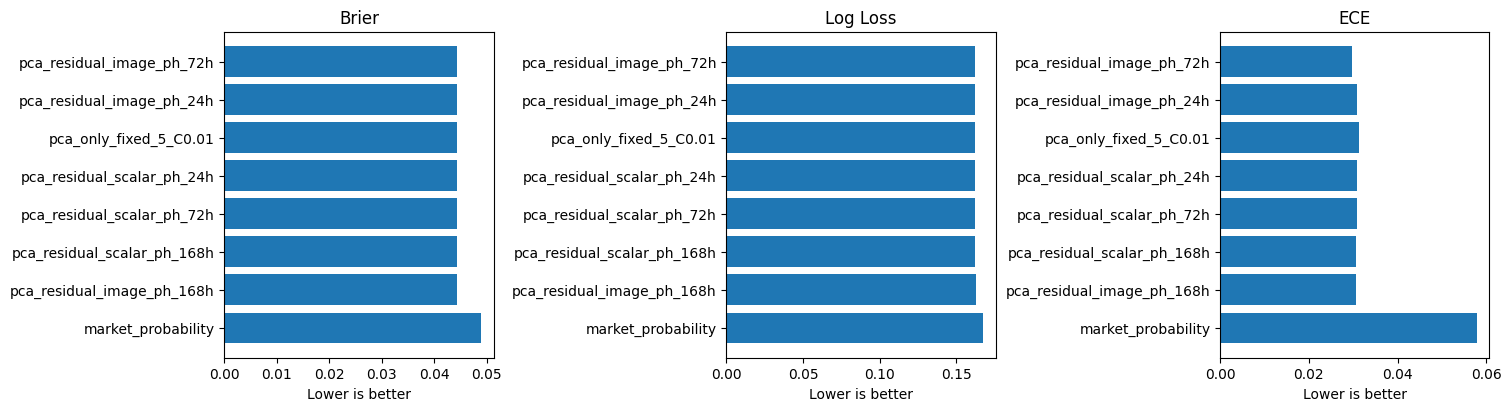

In [4]:
plot_df = summary[summary['representation'].isin([
    'market_probability', 'pca_only', 'pca_residual_scalar_ph', 'pca_residual_image_ph'
])].sort_values(['log_loss', 'brier']).head(10)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, metric, title in zip(axes, ['brier', 'log_loss', 'ece'], ['Brier', 'Log Loss', 'ECE']):
    ax.barh(plot_df['model'], plot_df[metric])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Lower is better')
plt.show()

## Residual Topology Diagnostics

,window_hours,folds,mean_h1_nontrivial_rate,mean_h0_total_persistence,mean_h1_total_persistence,mean_h1_image_mass
0,24,17,0.861101,2.162617,0.018320,0.017165
1,72,17,0.999677,6.357160,0.101672,0.095637
2,168,17,1.000000,14.661785,0.310007,0.290546


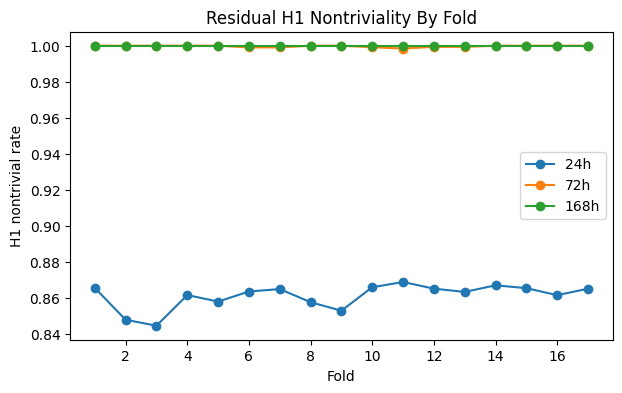

In [5]:
display(topology_features.groupby('window_hours', as_index=False).agg(
    folds=('fold', 'nunique'),
    mean_h1_nontrivial_rate=('h1_nontrivial_rate', 'mean'),
    mean_h0_total_persistence=('avg_h0_total_persistence', 'mean'),
    mean_h1_total_persistence=('avg_h1_total_persistence', 'mean'),
    mean_h1_image_mass=('avg_h1_image_mass', 'mean'),
))

fig, ax = plt.subplots(figsize=(7, 4))
for window, group in topology_features.groupby('window_hours'):
    ax.plot(group['fold'], group['h1_nontrivial_rate'], marker='o', label=f'{window}h')
ax.set_xlabel('Fold')
ax.set_ylabel('H1 nontrivial rate')
ax.set_title('Residual H1 Nontriviality By Fold')
ax.legend()
plt.show()

## Placebo Check

In [6]:
placebo_rows = summary[summary['placebo_type'].isin(['shuffle', 'future_shift'])].sort_values(['log_loss', 'brier']).head(12)
display(placebo_rows[['representation', 'model', 'window_hours', 'placebo_type', 'n_obs', 'brier', 'log_loss', 'ece']])

,representation,model,window_hours,placebo_type,n_obs,brier,log_loss,ece
5,pca_residual_image_ph_future_shift,pca_residual_image_ph_future_shift_168h,168,future_shift,142094,0.043200,0.158873,0.034663
14,pca_residual_scalar_ph_future_shift,pca_residual_scalar_ph_future_shift_168h,168,future_shift,142094,0.043359,0.159147,0.035026
19,pca_residual_scalar_ph_shuffle,pca_residual_scalar_ph_shuffle_72h,72,shuffle,282976,0.044359,0.162069,0.031362
7,pca_residual_image_ph_future_shift,pca_residual_image_ph_future_shift_72h,72,future_shift,222972,0.044465,0.162070,0.032089
10,pca_residual_image_ph_shuffle,pca_residual_image_ph_shuffle_72h,72,shuffle,282976,0.044360,0.162073,0.031184
18,pca_residual_scalar_ph_shuffle,pca_residual_scalar_ph_shuffle_24h,24,shuffle,282976,0.044364,0.162074,0.031353
17,pca_residual_scalar_ph_shuffle,pca_residual_scalar_ph_shuffle_168h,168,shuffle,282976,0.044363,0.162090,0.031330
9,pca_residual_image_ph_shuffle,pca_residual_image_ph_shuffle_24h,24,shuffle,282976,0.044370,0.162096,0.031211
8,pca_residual_image_ph_shuffle,pca_residual_image_ph_shuffle_168h,168,shuffle,282976,0.044368,0.162108,0.031173
16,pca_residual_scalar_ph_future_shift,pca_residual_scalar_ph_future_shift_72h,72,future_shift,222972,0.044470,0.162121,0.033570


## Calibration

,fold,representation,model,window_hours,placebo_type,prob_decile,n_obs,avg_pred,avg_actual
10,1,pca_only,pca_only_fixed_5_C0.01,0,none,0,11576,0.020416,0.019782
11,1,pca_only,pca_only_fixed_5_C0.01,0,none,1,783,0.142757,0.028097
12,1,pca_only,pca_only_fixed_5_C0.01,0,none,2,502,0.241589,0.047809
13,1,pca_only,pca_only_fixed_5_C0.01,0,none,3,196,0.358204,0.086735
14,1,pca_only,pca_only_fixed_5_C0.01,0,none,4,436,0.446631,0.575688
15,1,pca_only,pca_only_fixed_5_C0.01,0,none,5,311,0.555911,0.819936
16,1,pca_only,pca_only_fixed_5_C0.01,0,none,6,262,0.653464,0.671756
17,1,pca_only,pca_only_fixed_5_C0.01,0,none,7,326,0.765353,0.346626
18,1,pca_only,pca_only_fixed_5_C0.01,0,none,8,430,0.841285,0.406977
19,1,pca_only,pca_only_fixed_5_C0.01,0,none,9,28,0.913638,0.821429


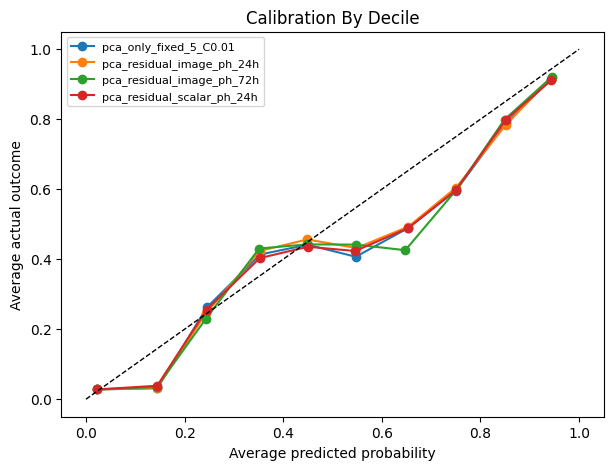

In [7]:
best_models = summary[summary['placebo_type'].eq('real')].sort_values(['log_loss', 'brier']).head(3)['model'].tolist()
best_models.append('pca_only_fixed_5_C0.01')
best_models = sorted(set(best_models))
cal = calibration[calibration['model'].isin(best_models)].copy()
display(cal.head(20))

fig, ax = plt.subplots(figsize=(7, 5))
for model, group in cal.groupby('model'):
    by_decile = group.groupby('prob_decile', as_index=False).agg(avg_pred=('avg_pred', 'mean'), avg_actual=('avg_actual', 'mean'))
    ax.plot(by_decile['avg_pred'], by_decile['avg_actual'], marker='o', label=model)
ax.plot([0, 1], [0, 1], color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Average predicted probability')
ax.set_ylabel('Average actual outcome')
ax.set_title('Calibration By Decile')
ax.legend(fontsize=8)
plt.show()